### Sleep Health & Lifestyle — Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
print('libraries loaded')

libraries loaded


In [4]:
# Reload with proper encoding
df = pd.read_csv("C:/Internships/projects/data/Sleep_health_and_lifestyle_dataset.csv", encoding='utf-8')

# Check columns now
print(df.columns.tolist())

['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


In [5]:
#shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

Rows: 374, Columns: 13



In [6]:
df.dtypes

Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
dtype: object

In [7]:
#missing values
print('Missing values: \n',df.isnull().sum())

Missing values: 
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [8]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [9]:
#data cleaning

In [10]:
df.columns.tolist()

['Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder']

In [11]:
df.columns = df.columns.str.strip().str.replace(' ', '_')


In [12]:
print(df.columns.tolist())

['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder']


In [13]:
print(df['BMI_Category'].unique())

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str


In [14]:
print(df['Sleep_Disorder'].unique())

<StringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str


In [15]:
df['BMI_Category']=df['BMI_Category'].replace('Normal Weight','Normal')
df['Sleep_Disorder']=df['Sleep_Disorder'].fillna('None')

In [16]:
print(df['BMI_Category'].unique())
print(df['Sleep_Disorder'].unique())

<StringArray>
['Overweight', 'Normal', 'Obese']
Length: 3, dtype: str
<StringArray>
['None', 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str


In [17]:
df.drop(columns=['Person_ID'], inplace=True)
print('Cleaning done')

Cleaning done


In [18]:
print('Final shape:\n',df.shape)

Final shape:
 (374, 12)


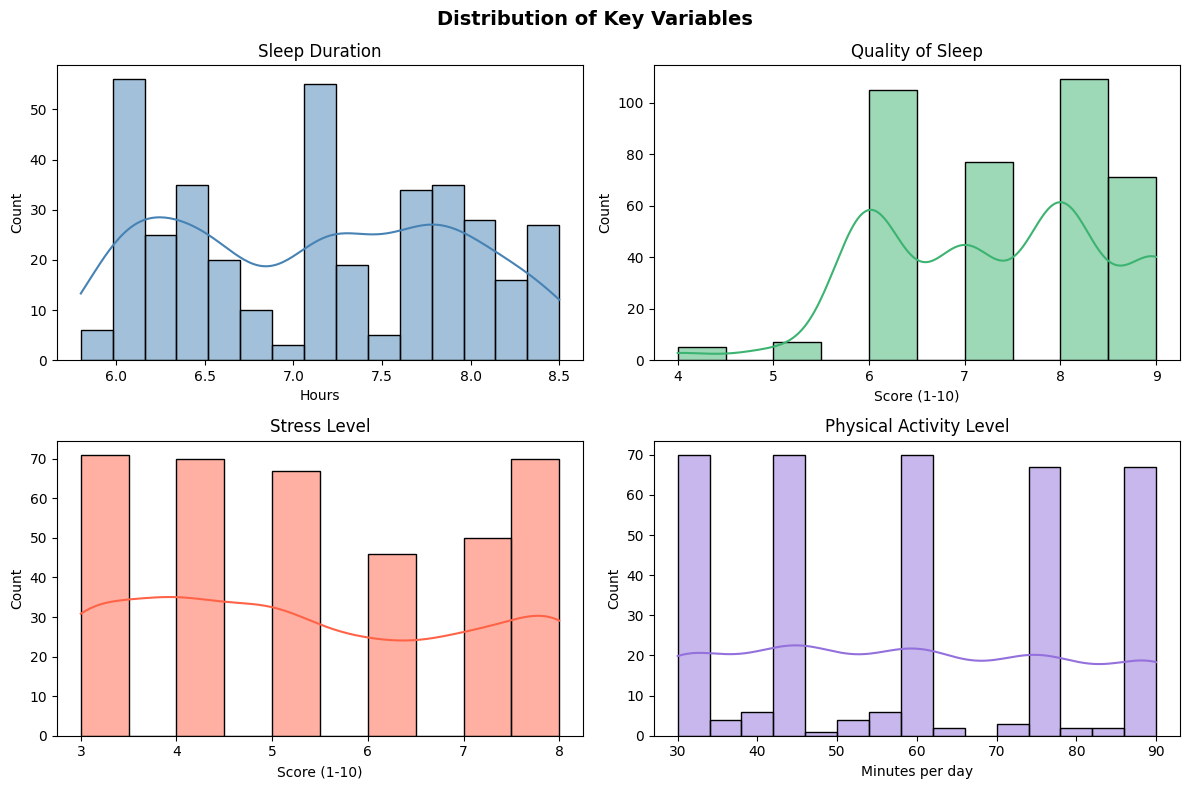

In [19]:
# histogram and distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Key Variables', fontsize=14, fontweight='bold')

# Sleep Duration
sns.histplot(df['Sleep_Duration'], bins=15, ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('Sleep Duration')
axes[0,0].set_xlabel('Hours')

# Sleep Quality
sns.histplot(df['Quality_of_Sleep'], bins=10, ax=axes[0,1], color='mediumseagreen', kde=True)
axes[0,1].set_title('Quality of Sleep')
axes[0,1].set_xlabel('Score (1-10)')

# Stress Level
sns.histplot(df['Stress_Level'], bins=10, ax=axes[1,0], color='tomato', kde=True)
axes[1,0].set_title('Stress Level')
axes[1,0].set_xlabel('Score (1-10)')

# Physical Activity
sns.histplot(df['Physical_Activity_Level'], bins=15, ax=axes[1,1], color='mediumpurple', kde=True)
axes[1,1].set_title('Physical Activity Level')
axes[1,1].set_xlabel('Minutes per day')

plt.tight_layout()
plt.show()

### Observations:
- **Sleep Duration**: Bimodal — two groups exist (short sleepers ~6hrs, healthy sleepers ~7hrs)
- **Quality of Sleep**: Bimodal — people either sleep okay (score 6) or well (score 8), very few in between
- **Stress Level**: Uniform — stress is evenly distributed across all levels, no dominant group
- **Physical Activity**: Multimodal — people follow fixed routines (30, 45, 60, 75, 90 mins), not random activity

In [68]:
#heatmap

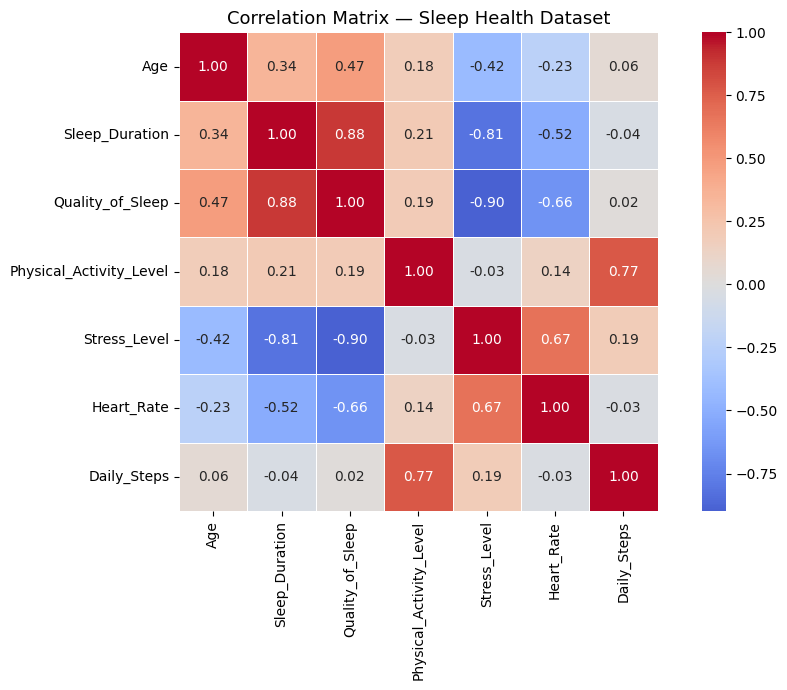

In [20]:
numeric_df=df.select_dtypes(include='number')
corr=numeric_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix — Sleep Health Dataset', fontsize=13)
plt.tight_layout()
plt.show()


### Observations:
- Stress Level has the strongest negative correlation with Sleep Quality (-0.90)
- Sleep Duration has the strongest positive correlation with Sleep Quality (+0.88)
- Heart Rate negatively impacts sleep quality (-0.66)
- Daily Steps has almost no impact on sleep quality (0.02)


In [22]:
#Deep Analysis

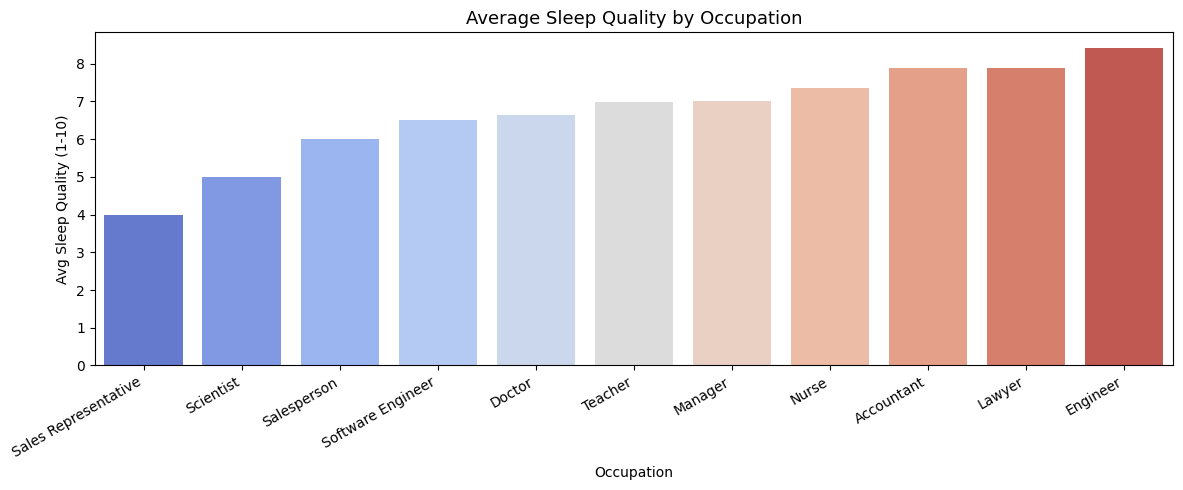

In [23]:
##Sleep Quality by Occupation 
plt.figure(figsize=(12,5))
occ_sleep = df.groupby('Occupation')['Quality_of_Sleep'].mean().sort_values()

sns.barplot(x=occ_sleep.index, y=occ_sleep.values, palette='coolwarm')
plt.title('Average Sleep Quality by Occupation', fontsize=13)
plt.xlabel('Occupation')
plt.ylabel('Avg Sleep Quality (1-10)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Observation:
- Sales Representatives have the worst sleep quality (avg 4/10)
- Engineers have the best sleep quality (avg 8.4/10)
- Occupation likely reflects underlying stress and work schedule differences

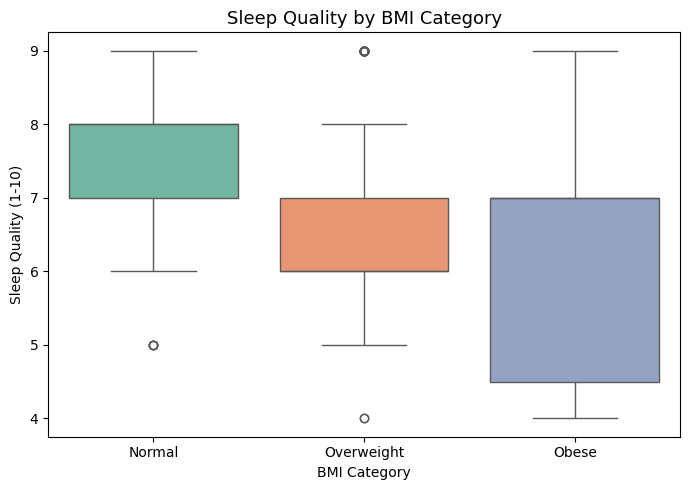

In [24]:
#Sleep Quality by BMI Category
plt.figure(figsize=(7, 5))

sns.boxplot(x='BMI_Category', y='Quality_of_Sleep', data=df,
            palette='Set2', order=['Normal', 'Overweight', 'Obese'])
plt.title('Sleep Quality by BMI Category', fontsize=13)
plt.xlabel('BMI Category')
plt.ylabel('Sleep Quality (1-10)')
plt.tight_layout()
plt.show()

## Observation
**BMI:**
- Normal weight individuals sleep significantly better than overweight/obese
- Obese individuals show the most inconsistent sleep patterns
- BMI appears to be a meaningful predictor of sleep quality

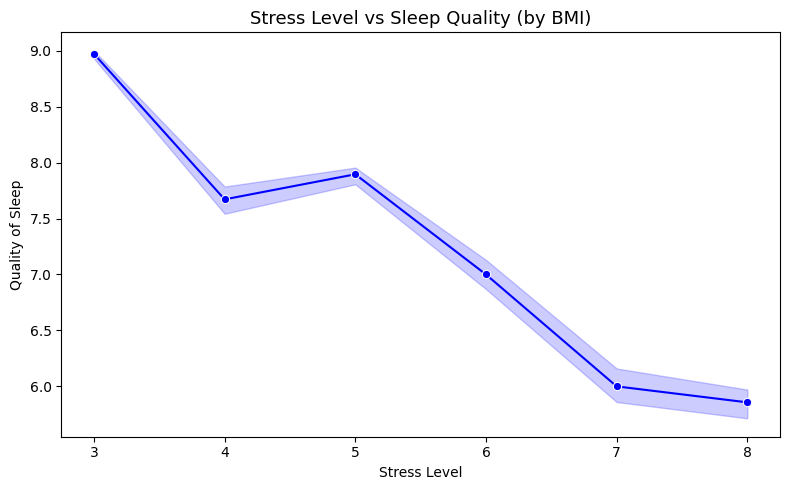

In [26]:
#Stress vs Sleep Quality
plt.figure(figsize=(8, 5))
sns.lineplot(x='Stress_Level', y='Quality_of_Sleep', data=df, marker='o', color='blue')
plt.title('Stress Level vs Sleep Quality (by BMI)', fontsize=13)
plt.xlabel('Stress Level')
plt.ylabel('Quality of Sleep')
plt.tight_layout()
plt.show()

## Observation:
**Stress vs Sleep:**
- Clear negative linear trend — every unit increase in stress drops sleep quality
- Stress level alone can almost predict sleep quality (correlation -0.90)
- This is the single most actionable insight — managing stress directly improves sleep

In [29]:
# Summary:

summary = df.groupby('Occupation')['Quality_of_Sleep'].agg(['mean', 'min', 'max']).round(2)
summary.columns = ['Avg Quality', 'Min Quality', 'Max Quality']
summary = summary.sort_values('Avg Quality', ascending=False)

print("Sleep Quality Summary by Occupation:")
print(summary)
print()
print(f"Overall Average Sleep Quality : {df['Quality_of_Sleep'].mean():.2f}")
print(f"Overall Average Stress Level  : {df['Stress_Level'].mean():.2f}")
print(f"Overall Average Sleep Duration: {df['Sleep_Duration'].mean():.2f} hrs")

Sleep Quality Summary by Occupation:
                      Avg Quality  Min Quality  Max Quality
Occupation                                                 
Engineer                     8.41            5            9
Accountant                   7.89            7            9
Lawyer                       7.89            7            8
Nurse                        7.37            5            9
Manager                      7.00            7            7
Teacher                      6.98            5            8
Doctor                       6.65            6            9
Software Engineer            6.50            4            8
Salesperson                  6.00            6            6
Scientist                    5.00            4            6
Sales Representative         4.00            4            4

Overall Average Sleep Quality : 7.31
Overall Average Stress Level  : 5.39
Overall Average Sleep Duration: 7.13 hrs


## Final Observations — Summary Statistics

### Overall Dataset:
- Average person sleeps **7.13 hours** with a sleep quality of **7.31/10**
- Average stress level sits at **5.39/10** — moderate but significant

### Occupation Breakdown:

**Top 3 Best Sleepers:**
- Engineers (8.41) — highest avg, consistent scores (5–9)
- Accountants (7.89) — tight range (7–9), very stable sleepers
- Lawyers (7.89) — same avg as accountants but narrower range (7–8)

**Bottom 3 Worst Sleepers:**
- Sales Representatives (4.00) — worst of all, zero variation (4–4)
  meaning every single sales rep in this dataset scores exactly 4
- Scientists (5.00) — second worst, low ceiling of only 6
- Salespersons (6.00) — also no variation (6–6), very rigid pattern

**Interesting patterns:**
- Managers score exactly 7.00 with zero variation (7–7) 
  — suggests managers as a group have very uniform sleep habits
- Salespersons and Sales Representatives are separate occupations
  in this dataset and both rank at the bottom
- Doctors have the widest range (6–9) — most inconsistent sleepers,
  likely due to shift work and on-call schedules
- Engineers have the highest ceiling AND the best average
  — genuinely the best sleeping profession in this dataset

### Bottom line:
High stress occupations (sales, science) consistently sleep worse.
Structured, office-based roles (engineering, accounting) sleep best.
This aligns perfectly with our correlation finding that
stress is the dominant factor affecting sleep quality.

## Limitations & Critical Thinking

While occupation shows a strong pattern, it is important to note that
sleep quality is never determined by a single factor alone.

A high-ranking occupation like Engineering may show great average sleep
quality, but an individual engineer with high stress, poor BMI, and low
physical activity could still sleep very poorly.

The real story is the **combination** of factors:
- High stress + poor BMI + low activity = poor sleep (regardless of occupation)
- Low stress + normal BMI + regular exercise = good sleep (regardless of occupation)

This dataset shows correlations, not causation. Real sleep health
is multidimensional and deeply personal.